In [38]:
VALID_PROVINCES = {
    "กระบี่", "กรุงเทพมหานคร", "กาญจนบุรี", "กาฬสินธุ์",
    "กำแพงเพชร", "ขอนแก่น", "จันทบุรี", "ฉะเชิงเทรา", "ชลบุรี",
    "ชัยนาท", "ชัยภูมิ", "ชุมพร", "เชียงราย", "เชียงใหม่",
    "ตรัง", "ตราด", "ตาก", "นครนายก", "นครปฐม",
    "นครพนม", "นครราชสีมา", "นครศรีธรรมราช", "นครสวรรค์", "นนทบุรี",
    "นราธิวาส", "น่าน", "บึงกาฬ", "บุรีรัมย์", "ปทุมธานี",
    "ประจวบคีรีขันธ์", "ปราจีนบุรี", "ปัตตานี", "พระนครศรีอยุธยา", "พะเยา",
    "พังงา", "พัทลุง", "พิจิตร", "พิษณุโลก", "เพชรบุรี",
    "เพชรบูรณ์", "แพร่", "ภูเก็ต", "มหาสารคาม", "มุกดาหาร",
    "แม่ฮ่องสอน", "ยโสธร", "ยะลา", "ร้อยเอ็ด", "ระนอง",
    "ระยอง", "ราชบุรี", "ลพบุรี", "ลำปาง", "ลำพูน",
    "เลย", "ศรีสะเกษ", "สกลนคร", "สงขลา", "สตูล",
    "สมุทรปราการ", "สมุทรสงคราม", "สมุทรสาคร", "สระแก้ว", "สระบุรี",
    "สิงห์บุรี", "สุโขทัย", "สุพรรณบุรี", "สุราษฎร์ธานี", "สุรินทร์",
    "หนองคาย", "หนองบัวลำภู", "อ่างทอง", "อำนาจเจริญ", "อุดรธานี",
    "อุตรดิตถ์", "อุทัยธานี", "อุบลราชธานี",
}


len(set(VALID_PROVINCES))

77

In [39]:
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
import cv2
import numpy as np
import re
from ultralytics import YOLO
from function.helper import get_thai_character, split_license_plate_and_province
import base64

app = FastAPI()

# ─── CORS ─────────────────────────────────────────────────────────────────────
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

vehicle_model = YOLO("model/license_plate.pt")
plate_model   = YOLO("model/data_plate.pt")


# ═══════════════════════════════════════════════════════════════════════════════
#  THAI PLATE VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════


_C = r"[\u0E01-\u0E4E]"   # Unicode range พยัญชนะไทย

# ┌─────────────────────────────────────────────────────────────────┐
# │  รูปแบบทะเบียนที่รองรับ                                          │
# │  (1) มาตรฐาน   : พยัญชนะ 2 ตัว  + เลข 1-4 หลัก  → กข 1234    │
# │  (2) หมวดใหม่  : เลข 1 หลัก + พยัญชนะ 2 ตัว + เลข 1-4 หลัก   │
# │                  → 1กข 1234                                     │
# │  (3) ป้ายประมูล: พยัญชนะ 3 ตัว + เลข 1-4 หลัก  → กขค 1234    │
# │                  (ต้องมีจังหวัด มิฉะนั้น reject)                  │
# └─────────────────────────────────────────────────────────────────┘
_RE_STANDARD  = re.compile(rf"^{_C}{{2}}\d{{1,4}}$")          # กข1234
_RE_NEW_SERIES = re.compile(rf"^\d{_C}{{2}}\d{{1,4}}$")        # 1กข1234
_RE_AUCTION   = re.compile(rf"^{_C}{{3}}\d{{1,4}}$")           # กขค1234 (ประมูล)
_RE_ANY_DIGITS = re.compile(r"\d+")


def is_valid_thai_plate(license_plate: str, province: str) -> tuple[bool, str]:
    """
    ตรวจสอบความถูกต้องของทะเบียนไทย
    คืนค่า (is_valid, reason)

    กฎหลัก
    -------
    1. ต้องมีทั้งทะเบียนและจังหวัด
    2. จังหวัดต้องอยู่ในรายการ 77 จังหวัด
    3. ตัวเลขต้องไม่เกิน 4 หลัก (≥ 5 หลัก = ป้ายปลอมแน่นอน)
    4. ตัวเลขต้องไม่เป็น 0 ทั้งหมด
    5. รูปแบบต้องตรงใดตรงหนึ่ง:
       • มาตรฐาน   [พยัญชนะ 2 ตัว][เลข 1-4]         กข1234
       • หมวดใหม่  [เลข 1 หลัก][พยัญชนะ 2 ตัว][เลข 1-4]  1กข1234
       • ป้ายประมูล [พยัญชนะ 3 ตัว][เลข 1-4]  (ต้องมีจังหวัด) กขค1234
    6. พยัญชนะ 3 ตัวโดยไม่มีจังหวัด = ผิด Logic ทันที
    """
    # ── 1. ต้องมีครบ ───────────────────────────────────────────────
    if not license_plate:
        return False, "ไม่พบทะเบียน"
    if not province:
        return False, "ไม่พบจังหวัด"

    plate = license_plate.strip()
    prov  = province.strip()

    # ── 2. จังหวัดถูกต้อง ──────────────────────────────────────────
    if prov not in VALID_PROVINCES:
        return False, f"จังหวัดไม่ถูกต้อง: '{prov}'"

    # ── 3. ตัวเลขต้องไม่เกิน 4 หลัก ───────────────────────────────
    for m in _RE_ANY_DIGITS.finditer(plate):
        if len(m.group()) >= 5:
            return False, f"ตัวเลขเกิน 4 หลัก ({m.group()}) → ป้ายปลอม"

    # ── 4. ตัวเลขต้องไม่เป็น 0 ทั้งหมด ────────────────────────────
    digits_only = "".join(re.findall(r"\d", plate))
    if digits_only and int(digits_only) == 0:
        return False, "เลขทะเบียนเป็น 0 ทั้งหมด"

    # ── 5 & 6. ตรวจ pattern ────────────────────────────────────────
    if _RE_STANDARD.match(plate):
        return True, "มาตรฐาน (พยัญชนะ 2 + เลข 1-4)"

    if _RE_NEW_SERIES.match(plate):
        return True, "หมวดใหม่ (เลข 1 + พยัญชนะ 2 + เลข 1-4)"

    if _RE_AUCTION.match(plate):
        # พยัญชนะ 3 ตัว = ป้ายประมูลพิเศษ → ยอมรับได้เฉพาะมีจังหวัด (ตรวจไปแล้วในข้อ 2)
        return True, "ป้ายประมูล (พยัญชนะ 3 + เลข 1-4)"

    return False, f"รูปแบบไม่ตรงกฎทะเบียนไทย: '{plate}'"


# ═══════════════════════════════════════════════════════════════════════════════
#  OVERLAP / DUPLICATE BOX DETECTION
# ═══════════════════════════════════════════════════════════════════════════════

def _box_overlap_ratio(a: tuple, b: tuple) -> float:
    """
    Overlap ratio = intersection / min(area_a, area_b)
    ใช้ min แทน union เพราะกรอบอักษรขนาดต่างกัน
    กรอบเล็กซ้อนอยู่ในกรอบใหญ่ก็ถือว่าทับกัน
    """
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1);  iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2);  iy2 = min(ay2, by2)

    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    inter   = inter_w * inter_h

    if inter == 0:
        return 0.0

    area_a = max(1, (ax2 - ax1) * (ay2 - ay1))
    area_b = max(1, (bx2 - bx1) * (by2 - by1))
    return inter / min(area_a, area_b)


def has_overlapping_boxes(boxes: list, threshold: float = 0.4) -> tuple:
    """
    ตรวจว่ามีกรอบคู่ไหนทับกันเกิน threshold หรือไม่
    boxes = list of (x1, y1, x2, y2)
    คืนค่า (has_overlap, reason)
    """
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            ratio = _box_overlap_ratio(boxes[i], boxes[j])
            print(f"Overlap ratio between box {i+1} and {j+1}: {ratio:.2f}")
            if ratio >= threshold:
                return True, (
                    f"กรอบที่ {i+1} และ {j+1} ทับกัน "
                    f"(overlap {ratio:.0%}) → detect ซ้ำ"
                )
    return False, ""


# ═══════════════════════════════════════════════════════════════════════════════
#  IMAGE PROCESSING
# ═══════════════════════════════════════════════════════════════════════════════

def process_image(image):
    """
    Returns:
        image     – annotated image (bounding boxes drawn)
        vehicles  – list of validated { license_plate, province, bbox }
        rejected  – list of rejected  { raw_text, reason, bbox }
    """
    vehicles = []
    rejected = []

    vehicle_results = vehicle_model(image, conf=0.5) #0.4
    print(f"Detected {len(vehicle_results)} vehicles in the image")
    for box in vehicle_results[0].boxes:
        print(f"Vehicle conf: {box.conf[0]:.2f}")

    for result in vehicle_results:
        for box in result.boxes:
            vx1, vy1, vx2, vy2 = map(int, box.xyxy[0])
            car_roi = image[vy1:vy2, vx1:vx2]

            plate_results = plate_model(car_roi, conf=0.6) #0.3
            print(f"Detected {len(plate_results)} plate characters in this vehicle box")
            for box in plate_results[0].boxes:
                print(f"Plate conf: {box.conf[0]:.2f}")
            # รวม character ของรถคันนี้
            plates = []
            for plate in plate_results:
                for plate_box in plate.boxes:
                    px1, py1, px2, py2 = map(int, plate_box.xyxy[0])
                    px1 += vx1; px2 += vx1
                    py1 += vy1; py2 += vy1
                    plates.append((px1, plate_box.cls, (px1, py1, px2, py2)))

            # เรียงซ้าย→ขวา (reading order)
            plates.sort(key=lambda x: x[0])

            vehicle_classes = []
            char_bboxes     = []
            for _, cls, (x1p, y1p, x2p, y2p) in plates:
                cv2.rectangle(image, (x1p, y1p), (x2p, y2p), (0, 255, 0), 2)
                vehicle_classes.append(plate_model.names[int(cls)])
                char_bboxes.append((x1p, y1p, x2p, y2p))

            if not vehicle_classes:
                continue

            # ── 1. ตรวจกรอบทับกัน (ก่อนอื่นเลย) ──────────────────────────────
            overlap, overlap_reason = has_overlapping_boxes(char_bboxes)
            if overlap:
                cv2.rectangle(image, (vx1, vy1), (vx2, vy2), (50, 50, 220), 2)
                rejected.append({
                    "raw_text": " ".join(vehicle_classes),
                    "reason":   overlap_reason,
                    "bbox":     [vx1, vy1, vx2, vy2],
                })
                continue

            n_boxes = len(vehicle_classes)

            combined_text = "".join([get_thai_character(c) for c in vehicle_classes])
            license_plate, province = split_license_plate_and_province(combined_text)

            print(f"Combined Text: {combined_text}")
            print(f"License Plate: {license_plate}, Province: {province}")

            # ── 2. Cross-check จำนวนกรอบ vs ตัวอักษรในผลลัพธ์ ─────────────────
            n_chars = len(license_plate)
            if province:
                n_boxes=n_boxes-1
            print(f"Number of Characters: {n_chars}, Number of Boxes: {n_boxes}")
            if n_chars != (n_boxes):
                cv2.rectangle(image, (vx1, vy1), (vx2, vy2), (50, 50, 220), 2)
                rejected.append({
                    "raw_text": combined_text,
                    "reason":   (
                        f"จำนวนกรอบ ({n_boxes}) "
                        f"≠ ตัวอักษรในผลลัพธ์ ({n_chars}) "
                        f"→ detect ไม่ครบหรือซ้ำ"
                    ),
                    "bbox": [vx1, vy1, vx2, vy2],
                })
                continue

            # ── 3. Validate รูปแบบทะเบียนไทย ──────────────────────────────────
            valid, reason = is_valid_thai_plate(license_plate, province)

            if valid:
                cv2.rectangle(image, (vx1, vy1), (vx2, vy2), (0, 200, 80), 2)
                cv2.putText(
                    image, license_plate,
                    (vx1, max(vy1 - 8, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 200, 80), 2, cv2.LINE_AA,
                )
                vehicles.append({
                    "license_plate": license_plate,
                    "province":      province,
                    "bbox":          [vx1, vy1, vx2, vy2],
                })
            else:
                cv2.rectangle(image, (vx1, vy1), (vx2, vy2), (50, 50, 220), 2)
                rejected.append({
                    "raw_text": combined_text,
                    "reason":   reason,
                    "bbox":     [vx1, vy1, vx2, vy2],
                })

    print("Rejected:", rejected)
    return image, vehicles, rejected

# ═══════════════════════════════════════════════════════════════════════════════
#  ENDPOINT
# ═══════════════════════════════════════════════════════════════════════════════
def detect_from_path(image_path: str):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"อ่านภาพไม่ได้: {image_path}")

    image, vehicles, rejected = process_image(image)

    return vehicles, rejected, image

In [40]:
# !pip install torchvision

In [41]:
vehicles, rejected, image = detect_from_path("/Users/Pd/Downloads/ไฟลโค้ดทั้งหมดอัพเดท 4-10-2568-1/7.licenseplate_detector/MyPhoto/479519054_122125836452670021_3534397149527398874_n.jpg")


0: 480x640 1 license_plate, 69.5ms
Speed: 3.2ms preprocess, 69.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
Detected 1 vehicles in the image
Vehicle conf: 0.76

0: 352x640 1 5, 1 7, 1 A01, 1 A30, 41.8ms
Speed: 1.0ms preprocess, 41.8ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
Detected 1 plate characters in this vehicle box
Plate conf: 0.82
Plate conf: 0.81
Plate conf: 0.80
Plate conf: 0.78
Overlap ratio between box 1 and 2: 0.00
Overlap ratio between box 1 and 3: 0.00
Overlap ratio between box 1 and 4: 0.00
Overlap ratio between box 2 and 3: 0.00
Overlap ratio between box 2 and 4: 0.00
Overlap ratio between box 3 and 4: 0.04
Combined Text: กพ57
License Plate: กพ57, Province: None
Number of Characters: 4, Number of Boxes: 4
Rejected: [{'raw_text': 'กพ57', 'reason': 'ไม่พบจังหวัด', 'bbox': [440, 1032, 727, 1187]}]


In [42]:
path_img="/Users/Pd/Downloads/ไฟลโค้ดทั้งหมดอัพเดท 4-10-2568-1/7.licenseplate_detector/MyPhoto/477779603_9533953216649732_6126283167877667326_n.jpg"
vehicles, rejected, image = detect_from_path(path_img)


0: 480x640 1 license_plate, 65.1ms
Speed: 2.0ms preprocess, 65.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)
Detected 1 vehicles in the image
Vehicle conf: 0.81

0: 352x640 1 1, 2 6s, 1 9, 1 A01, 1 A40, 1 BKK, 52.0ms
Speed: 1.2ms preprocess, 52.0ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 640)
Detected 1 plate characters in this vehicle box
Plate conf: 0.96
Plate conf: 0.95
Plate conf: 0.94
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.90
Plate conf: 0.82
Overlap ratio between box 1 and 2: 0.00
Overlap ratio between box 1 and 3: 0.00
Overlap ratio between box 1 and 4: 0.00
Overlap ratio between box 1 and 5: 0.00
Overlap ratio between box 1 and 6: 0.00
Overlap ratio between box 1 and 7: 0.00
Overlap ratio between box 2 and 3: 0.00
Overlap ratio between box 2 and 4: 0.00
Overlap ratio between box 2 and 5: 0.00
Overlap ratio between box 2 and 6: 0.00
Overlap ratio between box 2 and 7: 0.00
Overlap ratio between box 3 and 4: 0.00
Overlap ratio b

In [43]:
path_img="/Users/Pd/Downloads/ไฟลโค้ดทั้งหมดอัพเดท 4-10-2568-1/7.licenseplate_detector/MyPhoto/477420593_9447963105243331_6691281712983413035_n.jpg"
vehicles, rejected, image = detect_from_path(path_img)



0: 480x640 1 license_plate, 66.0ms
Speed: 3.4ms preprocess, 66.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Detected 1 vehicles in the image
Vehicle conf: 0.75

0: 352x640 1 7, 3 8s, 1 A01, 1 A21, 1 ATG, 82.8ms
Speed: 1.4ms preprocess, 82.8ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
Detected 1 plate characters in this vehicle box
Plate conf: 0.94
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.80
Overlap ratio between box 1 and 2: 0.00
Overlap ratio between box 1 and 3: 0.00
Overlap ratio between box 1 and 4: 0.00
Overlap ratio between box 1 and 5: 0.00
Overlap ratio between box 1 and 6: 0.00
Overlap ratio between box 1 and 7: 0.00
Overlap ratio between box 2 and 3: 0.00
Overlap ratio between box 2 and 4: 0.00
Overlap ratio between box 2 and 5: 0.00
Overlap ratio between box 2 and 6: 0.00
Overlap ratio between box 2 and 7: 0.00
Overlap ratio between box 3 and 4: 0.00
Overlap ratio betwee

In [44]:
path_img="/Users/Pd/Downloads/ไฟลโค้ดทั้งหมดอัพเดท 4-10-2568-1/7.licenseplate_detector/MyPhoto/476984000_2863795300449185_5685195009447550483_n.jpg"
vehicles, rejected, image = detect_from_path(path_img)


0: 448x640 1 license_plate, 129.1ms
Speed: 1.6ms preprocess, 129.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Detected 1 vehicles in the image
Vehicle conf: 0.73

0: 320x640 2 2s, 2 8s, 1 A10, 1 A44, 1 BKK, 324.2ms
Speed: 2.7ms preprocess, 324.2ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Detected 1 plate characters in this vehicle box
Plate conf: 0.96
Plate conf: 0.94
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.93
Plate conf: 0.85
Overlap ratio between box 1 and 2: 0.00
Overlap ratio between box 1 and 3: 0.00
Overlap ratio between box 1 and 4: 0.00
Overlap ratio between box 1 and 5: 0.00
Overlap ratio between box 1 and 6: 0.00
Overlap ratio between box 1 and 7: 0.00
Overlap ratio between box 2 and 3: 0.00
Overlap ratio between box 2 and 4: 0.00
Overlap ratio between box 2 and 5: 0.00
Overlap ratio between box 2 and 6: 0.00
Overlap ratio between box 2 and 7: 0.00
Overlap ratio between box 3 and 4: 0.00
Overlap ratio b

In [45]:
vehicles, rejected, image = detect_from_path("/Users/Pd/Downloads/ไฟลโค้ดทั้งหมดอัพเดท 4-10-2568-1/7.licenseplate_detector/MyPhoto/479519054_122125836452670021_3534397149527398874_n.jpg")


0: 480x640 1 license_plate, 72.0ms
Speed: 5.1ms preprocess, 72.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Detected 1 vehicles in the image
Vehicle conf: 0.76

0: 352x640 1 5, 1 7, 1 A01, 1 A30, 69.4ms
Speed: 2.2ms preprocess, 69.4ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)
Detected 1 plate characters in this vehicle box
Plate conf: 0.82
Plate conf: 0.81
Plate conf: 0.80
Plate conf: 0.78
Overlap ratio between box 1 and 2: 0.00
Overlap ratio between box 1 and 3: 0.00
Overlap ratio between box 1 and 4: 0.00
Overlap ratio between box 2 and 3: 0.00
Overlap ratio between box 2 and 4: 0.00
Overlap ratio between box 3 and 4: 0.04
Combined Text: กพ57
License Plate: กพ57, Province: None
Number of Characters: 4, Number of Boxes: 4
Rejected: [{'raw_text': 'กพ57', 'reason': 'ไม่พบจังหวัด', 'bbox': [440, 1032, 727, 1187]}]


In [46]:
vehicles

[]

In [47]:
rejected

[{'raw_text': 'กพ57',
  'reason': 'ไม่พบจังหวัด',
  'bbox': [440, 1032, 727, 1187]}]

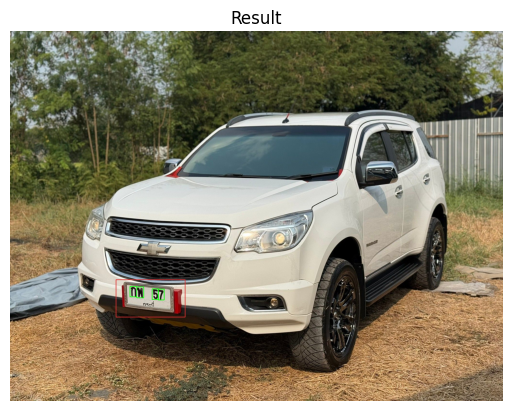

In [48]:
import matplotlib.pyplot as plt
import cv2

# ⚠️ แปลง BGR → RGB ก่อน (สำคัญมาก)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Result")
plt.axis("off")
plt.show()

In [49]:
data_province = [
    "กรุงเทพมหานคร", "เชียงราย", "เชียงใหม่", "น่าน", "พะเยา",
    "แพร่", "แม่ฮ่องสอน", "ลำปาง", "ลำพูน", "อุตรดิตถ์",
    "กาฬสินธุ์", "ขอนแก่น", "ชัยภูมิ", "นครพนม", "นครราชสีมา",
    "บึงกาฬ", "บุรีรัมย์", "มหาสารคาม", "มุกดาหาร", "ยโสธร",
    "ร้อยเอ็ด", "เลย", "ศรีสะเกษ", "สกลนคร", "สุรินทร์",
    "หนองคาย", "หนองบัวลำภู", "อำนาจเจริญ", "อุดรธานี", "อุบลราชธานี",
    "ชลบุรี", "ระยอง", "จันทบุรี", "ตราด", "ฉะเชิงเทรา",
    "ปราจีนบุรี", "สระแก้ว", "นครนายก", "สมุทรปราการ",
    "กาญจนบุรี", "ตาก", "ประจวบคีรีขันธ์", "เพชรบุรี", "ราชบุรี",
    "สุพรรณบุรี", "นครปฐม", "สมุทรสาคร", "สมุทรสงคราม",
    "กำแพงเพชร", "นครสวรรค์", "พิจิตร", "พิษณุโลก", "เพชรบูรณ์",
    "สุโขทัย", "อุทัยธานี", "อ่างทอง",
    "กระบี่", "ชุมพร", "ตรัง", "นครศรีธรรมราช", "นราธิวาส",
    "ปัตตานี", "พังงา", "พัทลุง", "ภูเก็ต", "ยะลา",
    "ระนอง", "สงขลา", "สตูล", "สุราษฎร์ธานี",
    "ชัยนาท", "สระบุรี", "สิงห์บุรี"
]

len(set(data_province))

73

In [50]:
provinces = {
    "BKK": "กรุงเทพมหานคร",
    "KKN": "ขอนแก่น",
    "CMI": "เชียงใหม่",
    "CRI": "เชียงราย",
    "CPM": "ชัยภูมิ",
    "CPN": "ชุมพร",
    "CTI": "จันทบุรี",
    "CBI": "ชลบุรี",
    "CCO": "ฉะเชิงเทรา",
    "KBI": "กระบี่",
    "KRI": "กาญจนบุรี",
    "KSN": "กาฬสินธุ์",
    "NKI": "นครศรีธรรมราช",
    "NMA": "นครสวรรค์",
    "NPM": "นครพนม",
    "NBP": "นครปฐม",
    "NBI": "นนทบุรี",
    "NAN": "น่าน",
    "NSN": "หนองคาย",
    "NBL": "หนองบัวลำภู",
    "NYK": "นครนายก",
    "PBI": "เพชรบุรี",
    "PCT": "เพชรบูรณ์",
    "PKN": "ประจวบคีรีขันธ์",
    "PKT": "ภูเก็ต",
    "PLG": "พัทลุง",
    "PLK": "พิษณุโลก",
    "PNA": "พังงา",
    "PNB": "ปัตตานี",
    "PRE": "แพร่",
    "PRI": "ปราจีนบุรี",
    "PTE": "ปทุมธานี",
    "PYO": "พะเยา",
    "PJR": "พิจิตร",
    "AYA": "พระนครศรีอยุธยา",
    "ATG": "อ่างทอง",
    "ACR": "อำนาจเจริญ",
    "RBR": "ราชบุรี",
    "RET": "ร้อยเอ็ด",
    "RNG": "ระนอง",
    "RYG": "ระยอง",
    "SBR": "สิงห์บุรี",
    "SKA": "สงขลา",
    "SKM": "สมุทรสงคราม",
    "SMK": "สมุทรสาคร",
    "SKW": "สมุทรปราการ",
    "SNI": "สระแก้ว",
    "SRB": "สระบุรี",
    "SPB": "สุพรรณบุรี",
    "SRI": "ศรีสะเกษ",
    "SRN": "สุรินทร์",
    "STI": "สตูล",
    "STK": "สุโขทัย",
    "SRT": "สุราษฎร์ธานี",
    "TAK": "ตาก",
    "TRG": "ตรัง",
    "TRT": "ตราด",
    "UBN": "อุบลราชธานี",
    "UDN": "อุดรธานี",
    "UTI": "อุตรดิตถ์",
    "UTT": "อุทัยธานี",
    "YLA": "ยะลา",
    "YST": "ยโสธร",
    "BKN": "บึงกาฬ",
    "BRM": "บุรีรัมย์",
    "LPG": "ลำปาง",
    "LPN": "ลำพูน",
    "LRI": "ลพบุรี",
    "LEI": "เลย",
    "MDH": "มหาสารคาม",
    "MKM": "แม่ฮ่องสอน",
    "NRM": "นครราชสีมา",
    "PHR": "พิจิตร",
    "NRW": "นราธิวาส",
    "SKN": "สกลนคร",   
    "CNT": "ชัยนาท",
    "KPT": "กำแพงเพชร",
    "MWI": "มุกดาหาร"
}

len(set(provinces.values()))

77